# Layer 8: thirty-two dimensions that earn their keep

A natural idea for a harder problem is "increase the input dimension". That works only with a
caveat worth making explicit: **ambient dimension alone does not create difficulty**. Rotating
a low-dimensional shape into $\mathbb R^{32}$ is a linear change of variables; the velocity
field barely gets harder, and the required model size barely moves. What sets the capacity a
field needs is the target's **intrinsic complexity**: how much structured geometry it must
encode.

So this notebook fills the 32 dimensions with structure: **sixteen** two-scale moon-pairs
(the plane construction of [notebook 07](07_flow_matching_hierarchical.ipynb)), stacked and
entangled by a fixed rotation of $\mathbb R^{32}$. It is the same class with
``n_pairs=16``. Difficulty across the series:

| notebook | dims | planes | per-plane | best grid model |
|---|---|---|---|---|
| [05](05_flow_matching.ipynb) | 2 | 1 | one-scale | saturates ${\sim}4.5\text{k}$ params |
| [06](06_flow_matching_hard.ipynb) | 8 | 4 | one-scale | ${\sim}10^5$ params |
| [07](07_flow_matching_hierarchical.ipynb) | 8 | 4 | two-scale | ${\sim}10^5\text{-}10^6$ params |
| **08** | 32 | 16 | two-scale | the grid extends to $2.4$M params, $D=2^{24}$ |

Sixteen entangled planes quadruple the structured content of notebook 07, so the
capacity-limited term $A/N^\alpha$ stays active into the million-parameter range, an order
of magnitude beyond notebook 07: the models finally stop being small.

dim=32 (16 two-scale planes), input (x_t, t) in R^33
LR law: eta*(w,T) = 0.00811 (w/64)^-0.368 (T/2048)^-0.18


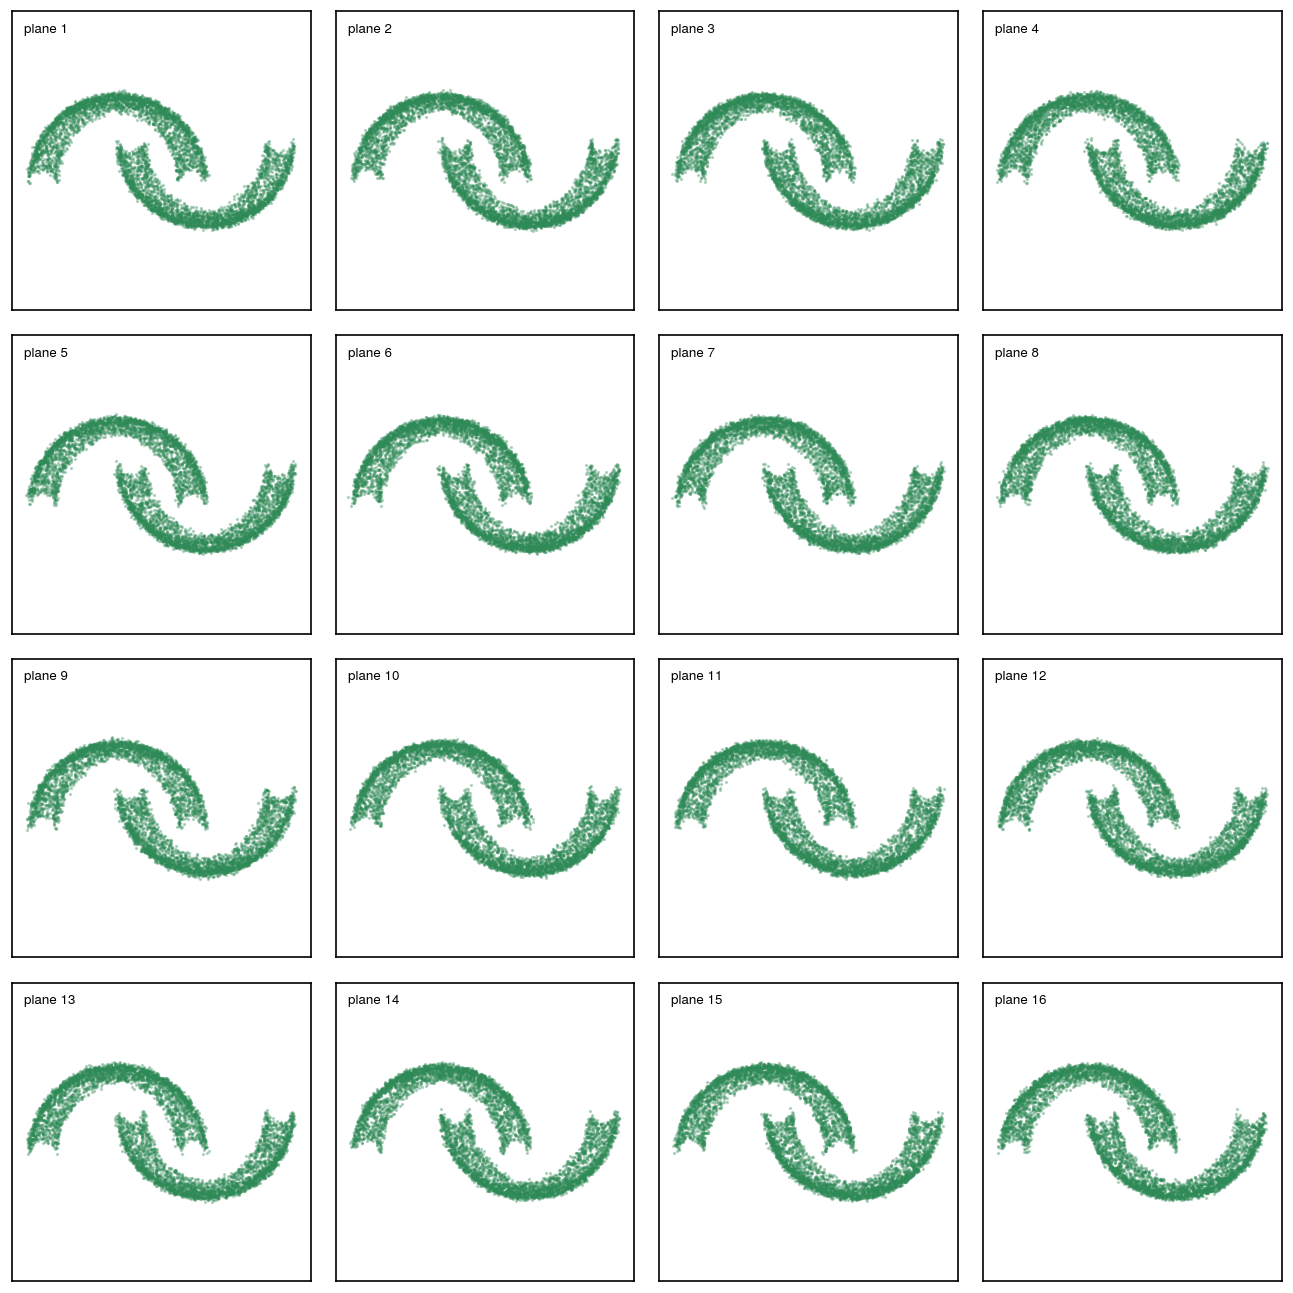

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from scaling_laws.flow import HierarchicalMoonsFlow
from scaling_laws.live import train_cell_live
from scaling_laws.sweep import aggregate, transfer_lr
from scaling_laws import approaches as ap, plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
prob = HierarchicalMoonsFlow(n_pairs=16)
law = json.load(open(RESULTS / "flow32_hp_study_cosine.json"))
lr_of = transfer_lr(eta_ref=law["eta_ref"], w_ref=law["w_ref"], T_ref=law["T_ref"],
                    c_w=law["c_w"], c_T=law["c_T"], lr_max=0.1)
print(f"dim={prob.dim} ({prob.n_pairs} two-scale planes), input (x_t, t) in R^{prob.input_dim}")
print(f"LR law: eta*(w,T) = {law['eta_ref']} (w/{law['w_ref']})^{law['c_w']} (T/{law['T_ref']})^{law['c_T']}")

xt = prob.unrotate(prob.sample_target(6000, torch.Generator().manual_seed(0)))
fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for j, a in enumerate(axes.ravel()):
    a.scatter(xt[:, 2*j], xt[:, 2*j+1], s=1, alpha=.3, color="seagreen")
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
    a.text(.04, .96, f"plane {j+1}", transform=a.transAxes, va="top", fontsize=8)
fig.tight_layout(); plt.show()

## The generation ladder

Plane 1 (top) and its zoomed arc (bottom) across a model/data ladder. With sixteen planes
sharing one network, small models cannot even draw the coarse arcs that sufficed in notebook
07; both scales keep improving to the largest cell.

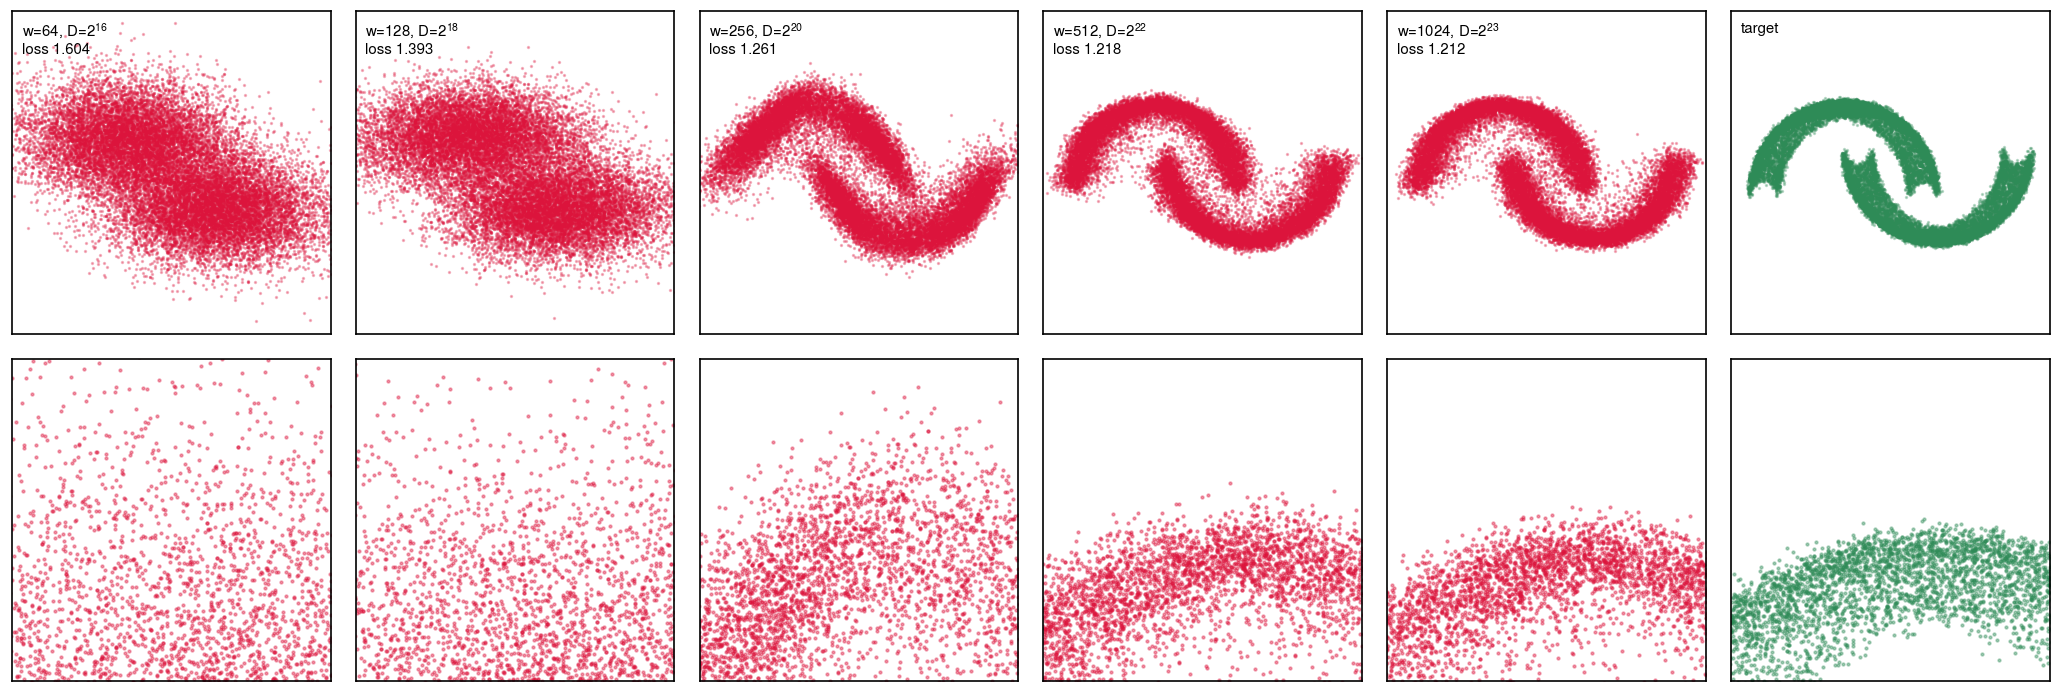

In [2]:
ZOOM = dict(xlim=(-1.8, -0.4), ylim=(0.8, 2.0))
ladder = [(64, 2**16), (128, 2**18), (256, 2**20), (512, 2**22), (1024, 2**23)]
fig, axes = plt.subplots(2, len(ladder) + 1, figsize=(2.9 * (len(ladder) + 1), 6.0))
for col, (w, D) in enumerate(ladder):
    lv, _, _, m = train_cell_live(prob, w, D, lr_of(w, prob.n_steps(D, 256)),
                                  plot=False, progress=False, return_model=True)
    xs = prob.unrotate(prob.sample(m, 20000, seed=2))
    axes[0, col].scatter(xs[:, 0], xs[:, 1], s=1, alpha=.3, color="crimson")
    axes[1, col].scatter(xs[:, 0], xs[:, 1], s=2.5, alpha=.4, color="crimson")
    axes[0, col].text(.03, .97, f"w={w}, D=$2^{{{int(np.log2(D))}}}$\nloss {lv:.3f}",
                      transform=axes[0, col].transAxes, va="top", fontsize=9)
xt20 = prob.unrotate(prob.sample_target(20000, torch.Generator().manual_seed(3)))
axes[0, -1].scatter(xt20[:, 0], xt20[:, 1], s=1, alpha=.3, color="seagreen")
axes[1, -1].scatter(xt20[:, 0], xt20[:, 1], s=2.5, alpha=.4, color="seagreen")
axes[0, -1].text(.03, .97, "target", transform=axes[0, -1].transAxes, va="top", fontsize=9)
for a in axes[0]:
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
for a in axes[1]:
    a.set(**ZOOM); a.set(xticks=[], yticks=[])
fig.tight_layout()
pl.save_figure(fig, "flow32_generation_ladder", outdir=FIGDIR); plt.show()

## The grid, three ways

[`run_flow_sweep.py --dim32`](../scripts/run_flow_sweep.py): widths 32 to 1536 (up to 2.4M
parameters), $D$ to $2^{24}$, per-cell LR from a law calibrated out to $w{=}512$ and
$T{=}32768$.

grid: 8 model sizes x 14 data budgets, N from 3,200 to 2,462,240 params


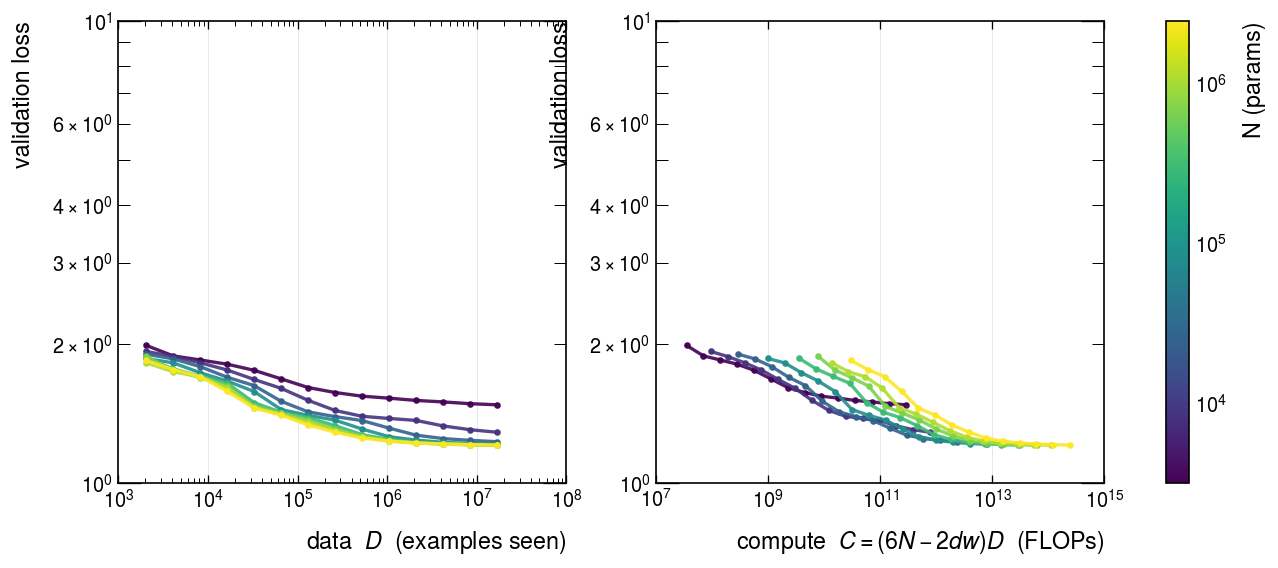

In [3]:
agg = aggregate(pd.read_csv(RESULTS / "flow32_sweep_cosine.csv"))
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data budgets, "
      f"N from {agg['N'].min():,} to {agg['N'].max():,} params")
fig = pl.plot_all_runs(agg)
pl.save_figure(fig, "flow32_overview", outdir=FIGDIR); plt.show()

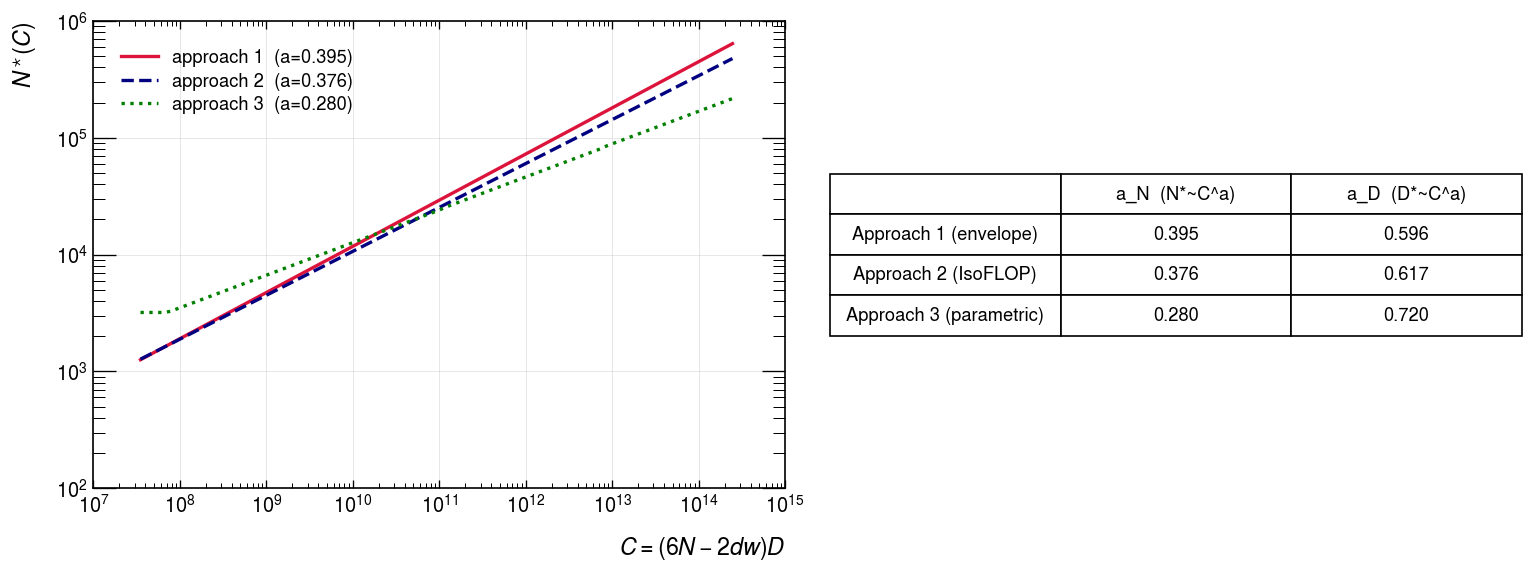

fitted floor (Approach 3):  E = 1.0780
exponents: alpha = 0.641, beta = 0.250, a_N = 0.280


In [4]:
env = ap.training_curve_envelope(agg)
iso = ap.isoflop_profiles(agg, n_targets=8)
par = ap.parametric_fit(agg)
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "flow32_comparison", outdir=FIGDIR); plt.show()
print(f"fitted floor (Approach 3):  E = {par.E:.4f}")
print(f"exponents: alpha = {par.alpha:.3f}, beta = {par.beta:.3f}, a_N = {par.a_N:.3f}")

## Floor and excess

At 32 dimensions the importance-sampling weights degenerate quickly, so the estimator is
reported for completeness but the empirical bound comes from the best trained cells and the
fitted $E$ from Approach 3. The largest grid cell (2.4M parameters at $D=2^{24}$) plays the
role of the reference model.

In [5]:
val_ref = float(agg["val_loss"].min())
E_is, ess = prob.estimate_floor(n_points=1024, t_max=0.9)
print(f"best grid cell (w=1536, D=2^24): loss = {val_ref:.4f}   <- empirical floor bound")
print(f"Approach 3 fitted floor:         E    = {par.E:.4f}")
print(f"IS floor, t<=0.9:                E    = {E_is:.4f}  (mean ESS {ess:.0f}; "
      f"weak in 32D, indicative only)")

best grid cell (w=1536, D=2^24): loss = 1.2091   <- empirical floor bound
Approach 3 fitted floor:         E    = 1.0780
IS floor, t<=0.9:                E    = 1.1137  (mean ESS 19773; weak in 32D, indicative only)


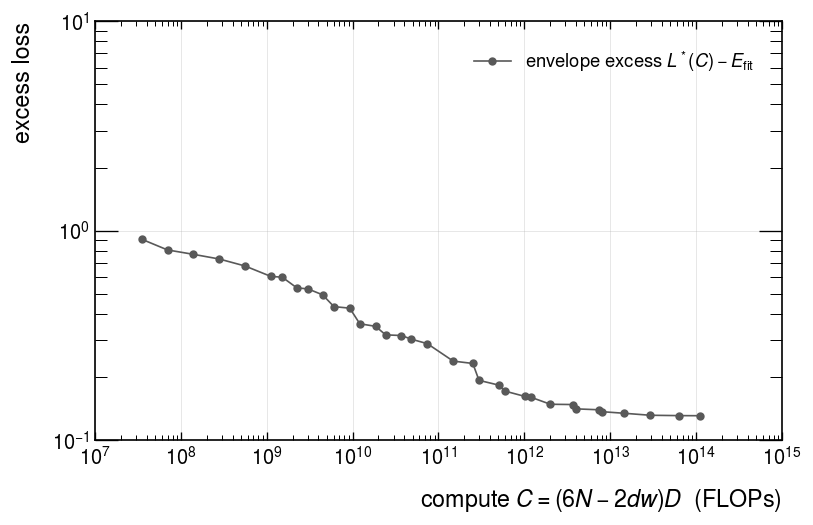

In [6]:
fr = env.frontier.sort_values("C")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(fr["C"], fr["val_loss"] - par.E, "o-", color="0.35", ms=4, lw=1,
        label=r"envelope excess $L^*(C)-E_{\rm fit}$")
ax.set(xscale="log", yscale="log", xlabel=r"compute $C=(6N-2dw)D$  (FLOPs)",
       ylabel="excess loss")
ax.legend(frameon=False)
fig.tight_layout()
pl.save_figure(fig, "flow32_excess", outdir=FIGDIR); plt.show()

## Takeaways

- **Dimension counts only when it carries structure.** The jump from 8 to 32 dimensions
  mattered because the planes quadrupled, not because the ambient space grew; a bare rotation
  into 32D would have left the frontier almost unchanged.
- **The models finally stop being small.** With sixteen entangled two-scale planes the
  frontier keeps improving into the million-parameter range, an order of magnitude beyond
  notebook 07, before flattening around $w\approx1024$.
- **The recipe is unchanged at every scale**: the same problem class, law calibration, grid
  script and three extraction approaches carried from 2 to 32 dimensions.
- **Batch size is held fixed** at $b=256$ throughout; in principle it should be tuned and
  scaled jointly with $\eta$.